In [34]:
import string
import base64
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV


                                    Section 2 Supervised Learning


-----------------------------------------------------------------------------------------------------------------

In [1]:


dataSet = pd.read_parquet(r"C:\Users\A.RUSSO\PycharmProjects\JupyterProject\data\ssh_attacks.parquet")

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)

NameError: name 'pd' is not defined

Classification Report TEST:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       0.24      0.20      0.22     27717
       Harmless       0.00      0.00      0.00       670
         Impact       0.00      0.00      0.00         2
          Other       0.00      0.00      0.00       103
    Persistence       0.91      1.00      0.95     63431

      micro avg       0.85      0.83      0.84    167216
      macro avg       0.31      0.31      0.31    167216
   weighted avg       0.80      0.83      0.81    167216
    samples avg       0.87      0.85      0.84    167216

--------------------------------
Classification Report TRAIN:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       0.24      0.20      0.22   

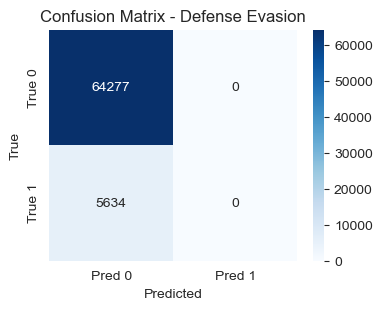

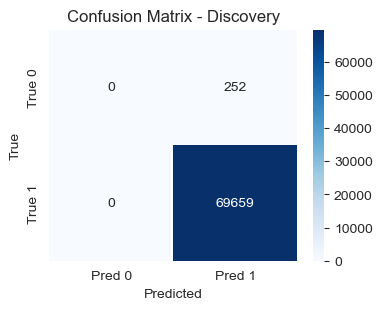

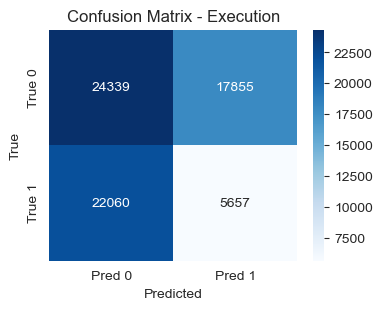

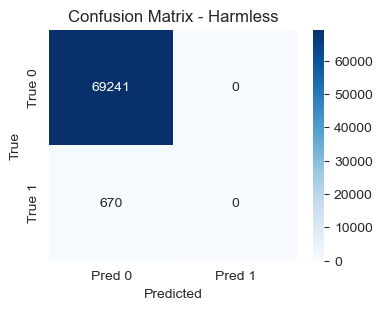

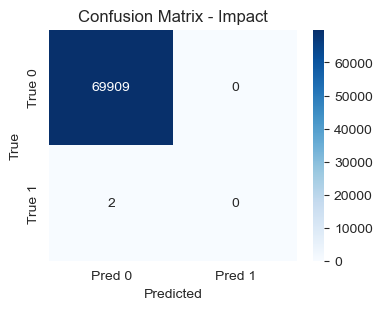

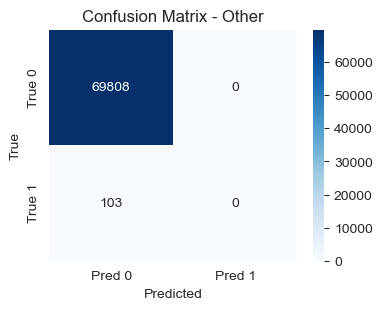

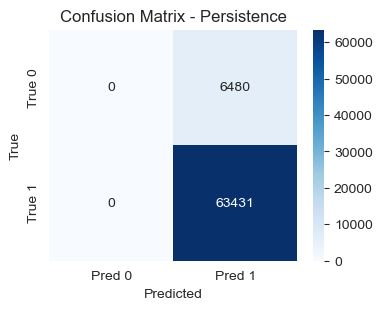

In [31]:
newDataSet = dataSet.copy()

# testo
newDataSet["decoded_payload"] = newDataSet["full_session"].fillna("").astype(str)

# timestamp features
newDataSet["first_timestamp"] = pd.to_datetime(newDataSet["first_timestamp"])
newDataSet["day_of_the_week"] = newDataSet["first_timestamp"].dt.dayofweek
newDataSet["month"] = newDataSet["first_timestamp"].dt.month

# target
y = newDataSet['Set_Fingerprint']
binary = MultiLabelBinarizer()
y = binary.fit_transform(y)

# drop colonne inutili
newDataSet.drop(columns=['Set_Fingerprint','full_session','session_id'], inplace=True)

# split
X_train, X_test, y_train, y_test = train_test_split(
    newDataSet,
    y,
    train_size=0.7,
    random_state=42,
)

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(lowercase=True, token_pattern=""),
            "decoded_payload"
        ),
        (
            "time",
            StandardScaler(),
            ["day_of_the_week", "month"]
        )
    ]
)

# pipeline
X_model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=3000)
    ))
])

# training
X_model.fit(X_train, y_train)

# prediction
y_pred_test = X_model.predict(X_test)
y_pred_train = X_model.predict(X_train)

# report
print("Classification Report TEST:\n")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=binary.classes_,
    zero_division=0
))

print("--------------------------------")

print("Classification Report TRAIN:\n")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=binary.classes_,
    zero_division=0
))

# confusion matrices
cms = multilabel_confusion_matrix(y_test, y_pred_test)

for i, label in enumerate(binary.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


ALTRO MODELLO

Classification Report TEST:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       0.46      0.32      0.38     27717
       Harmless       0.00      0.00      0.00       670
         Impact       0.00      0.00      0.00         2
          Other       0.00      0.00      0.00       103
    Persistence       0.91      1.00      0.95     63431

      micro avg       0.89      0.85      0.87    167216
      macro avg       0.34      0.33      0.33    167216
   weighted avg       0.84      0.85      0.84    167216
    samples avg       0.91      0.87      0.87    167216

--------------------------------
Classification Report TRAIN:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       0.46      0.32      0.37   

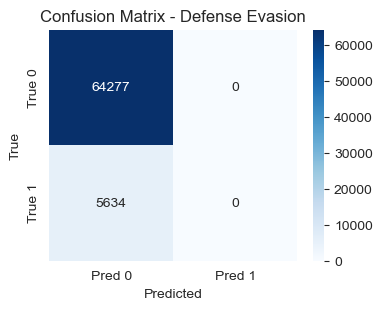

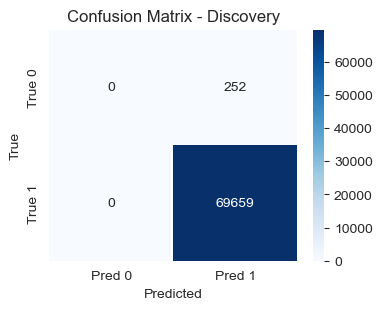

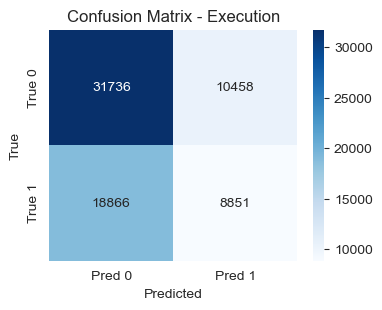

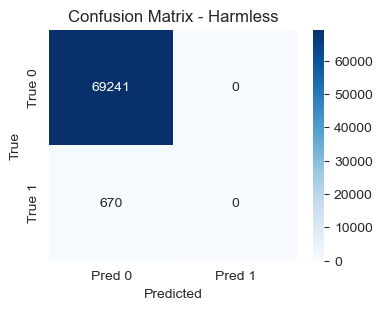

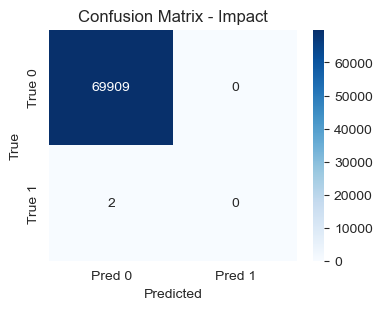

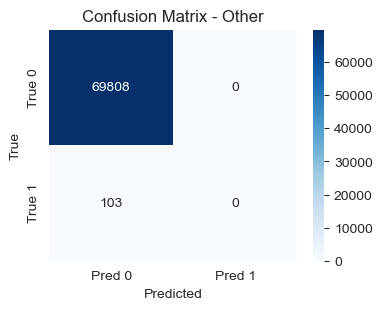

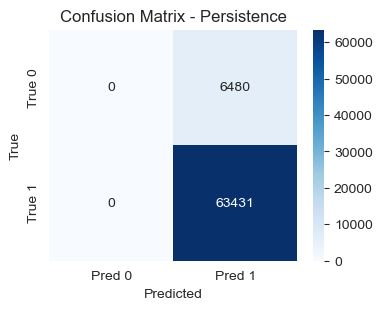

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(lowercase=True, token_pattern=""),
            "decoded_payload"
        ),
        (
            "time",
            "passthrough",
            ["day_of_the_week", "month"]
        )
    ]
)


X_model_NB = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", OneVsRestClassifier(
        MultinomialNB()
    ))
])

X_model_NB.fit(X_train, y_train)

y_pred_test = X_model_NB.predict(X_test)
y_pred_train = X_model_NB.predict(X_train)

print("Classification Report TEST:\n")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=binary.classes_,
    zero_division=0
))
print("--------------------------------")
print("Classification Report TRAIN:\n")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=binary.classes_,
    zero_division=0
))


# Confusion matrices (one per label)
cms = multilabel_confusion_matrix(y_test, y_pred_test)



for i, label in enumerate(binary.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

CROSS-VALIDATION HYPERPARAMETERS PER LA LOGISTIC

C:\Users\A.RUSSO\AppData\Local\Temp\ipykernel_14628\1290413198.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heatmap_dfL["param_clf__estimator__C"] = heatmap_dfL["param_clf__estimator__C"].astype(str)


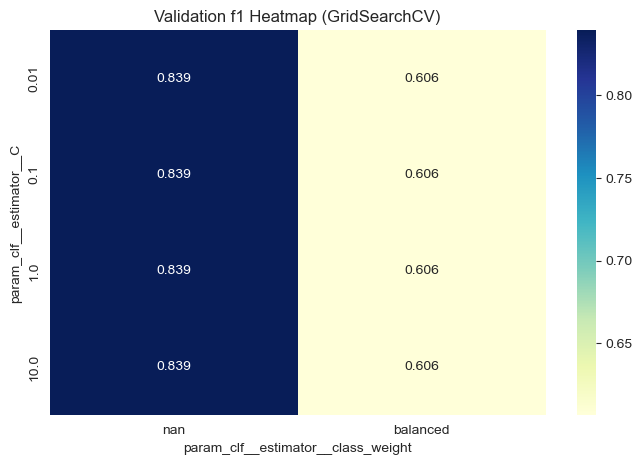

In [35]:
param_grid_logreg = {
    "clf__estimator__C": [0.01, 0.1, 1, 10],
    "clf__estimator__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=X_model,
    param_grid=param_grid_logreg,
    cv=5,
    scoring="f1_micro",
    return_train_score=False,
    n_jobs=-1
)

grid.fit(X_train, y_train)


df_gridL = pd.DataFrame(grid.cv_results_)
heatmap_dfL = df_gridL[[
    "param_clf__estimator__C",
    "param_clf__estimator__class_weight",
    "mean_test_score"
]].copy()
heatmap_dfL["param_clf__estimator__C"] = heatmap_dfL["param_clf__estimator__C"].astype(str)
heatmap_data = heatmap_dfL.pivot(
    index="param_clf__estimator__C",
    columns="param_clf__estimator__class_weight",
    values="mean_test_score"
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Validation f1 Heatmap (GridSearchCV)")
plt.ylabel("param_clf__estimator__C")
plt.xlabel("param_clf__estimator__class_weight")
plt.show()


VALIDATION CURVE PER L'ALTRO ALGORITMO

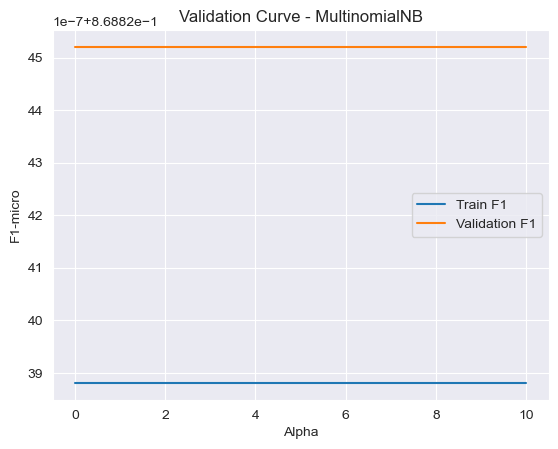

In [36]:
from sklearn.model_selection import validation_curve


param_range = [0.01, 0.1, 1, 10]
train_scores, test_scores = validation_curve(
    X_model_NB,       # Pipeline con TF-IDF + OneVsRest + NB
    X_train,
    y_train,
    param_name="clf__estimator__alpha",
    param_range=param_range,
    cv=5,
    scoring="f1_micro",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


plt.plot(param_range, train_mean, label="Train F1")
plt.plot(param_range, test_mean, label="Validation F1")
plt.xlabel("Alpha")
plt.ylabel("F1-micro")
plt.title("Validation Curve - MultinomialNB")
plt.legend()
plt.show()


VEDIAMO TOGLIENDO LE FEATURE TEMPORALI

Classification Report TEST:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       0.00      0.00      0.00     27717
       Harmless       0.00      0.00      0.00       670
         Impact       0.00      0.00      0.00         2
          Other       0.00      0.00      0.00       103
    Persistence       0.91      1.00      0.95     63431

      micro avg       0.95      0.80      0.87    167216
      macro avg       0.27      0.29      0.28    167216
   weighted avg       0.76      0.80      0.78    167216
    samples avg       0.95      0.82      0.87    167216

--------------------------------
Classification Report TRAIN:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       0.00      0.00      0.00   

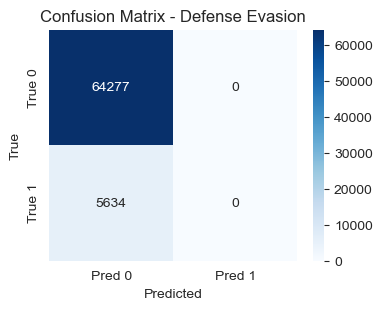

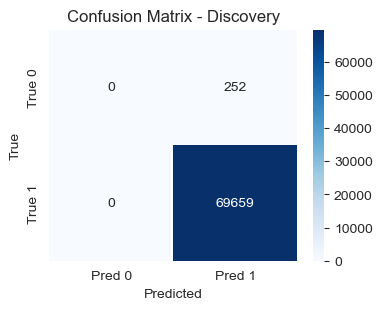

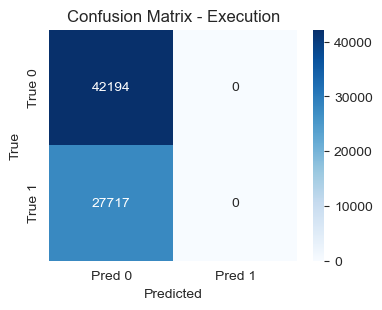

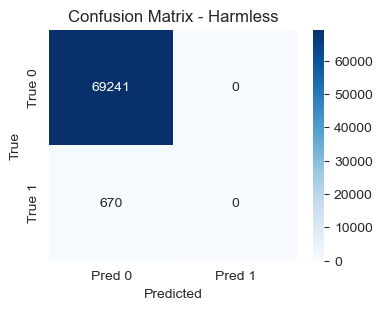

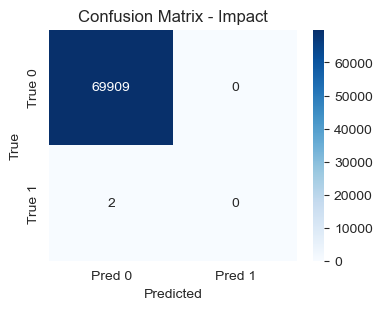

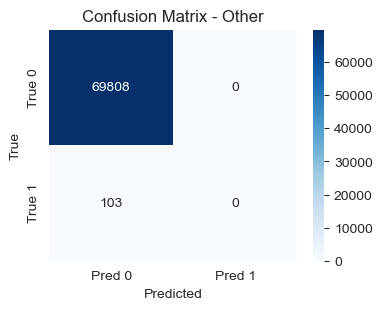

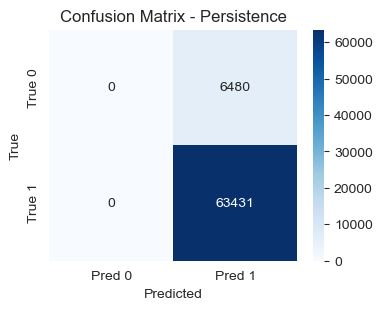

In [41]:
# drop colonne inutili
newDataSetT = newDataSet.drop(columns=['month','day_of_the_week'])

# split
X_train, X_test, y_train, y_test = train_test_split(
    newDataSetT,
    y,
    train_size=0.7,
    random_state=42,
)

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(lowercase=True, token_pattern=""),
            "decoded_payload"
        ),
    ]
)

# pipeline
X_model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=3000)
    ))
])

# training
X_model.fit(X_train, y_train)

# prediction
y_pred_test = X_model.predict(X_test)
y_pred_train = X_model.predict(X_train)

# report
print("Classification Report TEST:\n")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=binary.classes_,
    zero_division=0
))

print("--------------------------------")

print("Classification Report TRAIN:\n")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=binary.classes_,
    zero_division=0
))

# confusion matrices
cms = multilabel_confusion_matrix(y_test, y_pred_test)

for i, label in enumerate(binary.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


UTILIZZIAMO INVECE I BOW

Classification Report TEST:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       1.00      0.98      0.99     27717
       Harmless       0.00      0.00      0.00       670
         Impact       0.00      0.00      0.00         2
          Other       0.63      0.96      0.76       103
    Persistence       0.99      1.00      0.99     63431

      micro avg       0.99      0.96      0.97    167216
      macro avg       0.52      0.56      0.53    167216
   weighted avg       0.96      0.96      0.96    167216
    samples avg       0.99      0.95      0.96    167216

--------------------------------
Classification Report TRAIN:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       1.00      0.98      0.99   

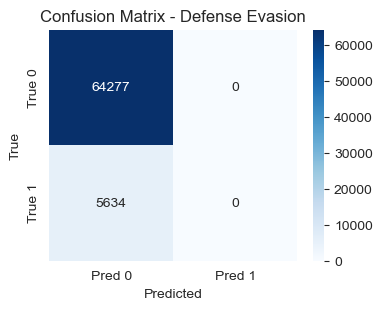

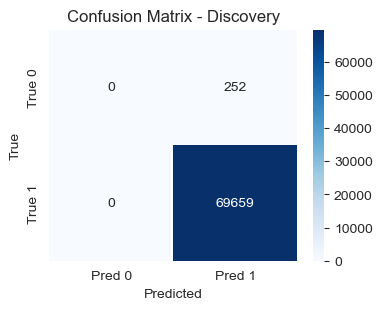

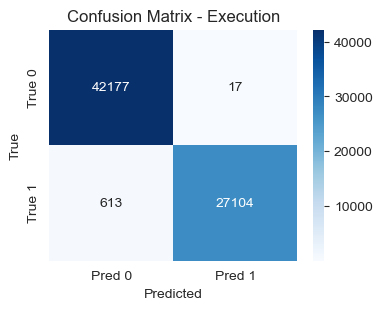

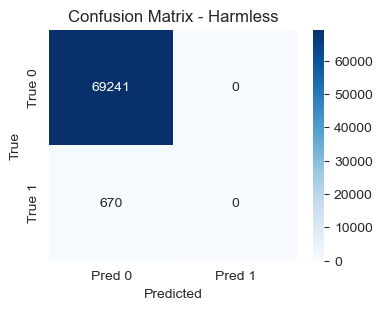

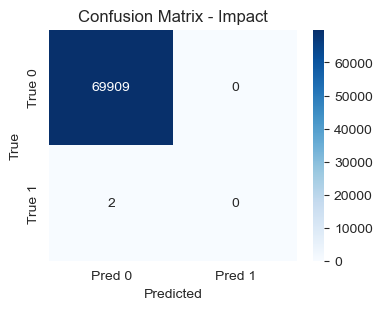

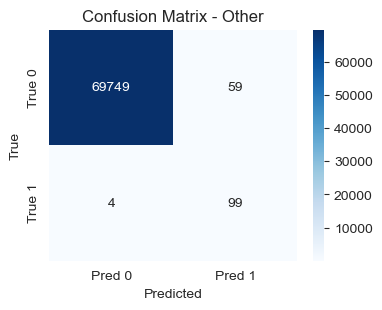

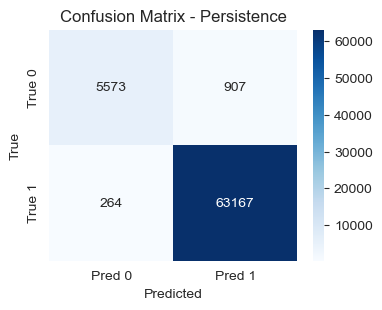

In [42]:
from sklearn.feature_extraction.text import CountVectorizer


# split
X_train, X_test, y_train, y_test = train_test_split(
    newDataSetT,
    y,
    train_size=0.7,
    random_state=42,
)

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            CountVectorizer(lowercase=True, token_pattern=""),
            "decoded_payload"
        ),
    ]
)

# pipeline
X_model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=3000)
    ))
])

# training
X_model.fit(X_train, y_train)

# prediction
y_pred_test = X_model.predict(X_test)
y_pred_train = X_model.predict(X_train)

# report
print("Classification Report TEST:\n")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=binary.classes_,
    zero_division=0
))

print("--------------------------------")

print("Classification Report TRAIN:\n")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=binary.classes_,
    zero_division=0
))

# confusion matrices
cms = multilabel_confusion_matrix(y_test, y_pred_test)

for i, label in enumerate(binary.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


Classification Report TEST:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00      5634
      Discovery       1.00      1.00      1.00     69659
      Execution       1.00      0.98      0.99     27717
       Harmless       0.00      0.00      0.00       670
         Impact       0.00      0.00      0.00         2
          Other       0.63      0.96      0.76       103
    Persistence       0.99      1.00      0.99     63431

      micro avg       0.99      0.96      0.97    167216
      macro avg       0.52      0.56      0.53    167216
   weighted avg       0.96      0.96      0.96    167216
    samples avg       0.99      0.95      0.96    167216

--------------------------------
Classification Report TRAIN:

                 precision    recall  f1-score   support

Defense Evasion       0.00      0.00      0.00     13365
      Discovery       1.00      1.00      1.00    162486
      Execution       1.00      0.98      0.99   

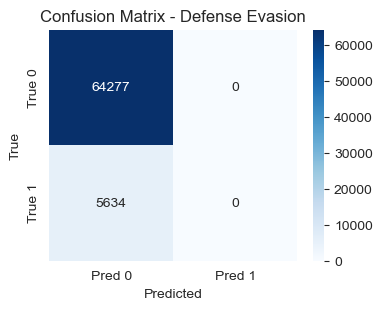

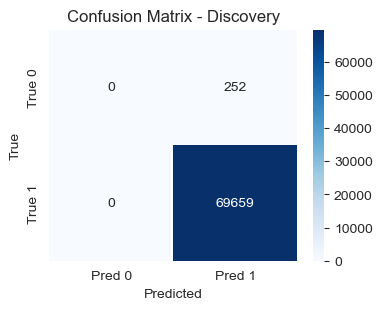

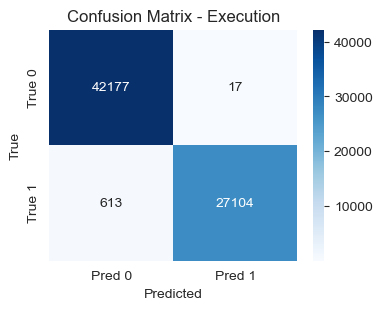

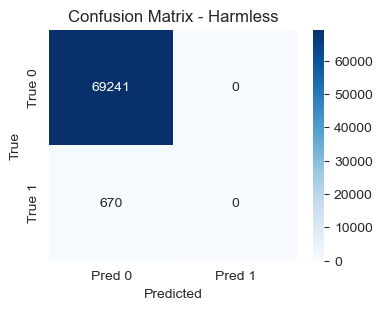

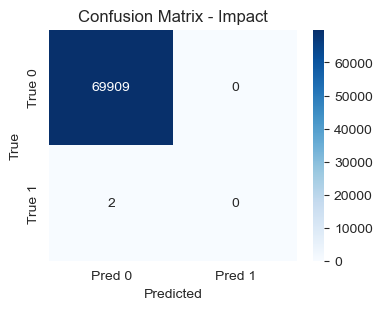

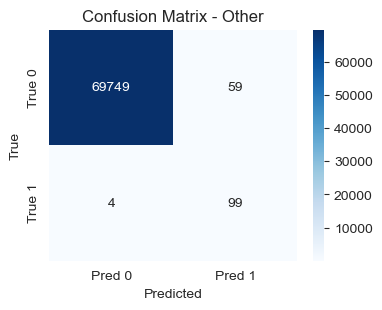

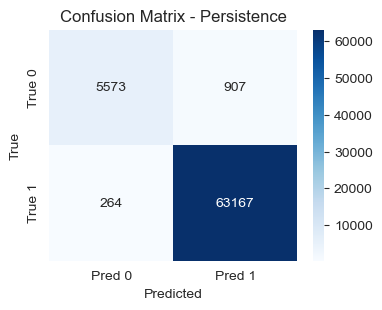

In [43]:
from sklearn.feature_extraction.text import CountVectorizer


# split
X_train, X_test, y_train, y_test = train_test_split(
    newDataSet,
    y,
    train_size=0.7,
    random_state=42,
)

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            CountVectorizer(lowercase=True, token_pattern=""),
            "decoded_payload"
        ),
    ]
)

# pipeline
X_model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=3000)
    ))
])

# training
X_model.fit(X_train, y_train)

# prediction
y_pred_test = X_model.predict(X_test)
y_pred_train = X_model.predict(X_train)

# report
print("Classification Report TEST:\n")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=binary.classes_,
    zero_division=0
))

print("--------------------------------")

print("Classification Report TRAIN:\n")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=binary.classes_,
    zero_division=0
))

# confusion matrices
cms = multilabel_confusion_matrix(y_test, y_pred_test)

for i, label in enumerate(binary.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
#funzione che serve a generalizzare le varie casistiche

def casesFuncion(preprocessor, dataSet):

    if preprocessor == "tf-idf":
        print("Utiliziamo per il preprocessing la tf-idf")
        if dataSet == "time":
            print("Utiliziamo il dataSet con le feature temporale.")
        else:
            print("Utiliziamo il dataSet senza le feature temporali.")


    elif preprocessor == "bow":
        print("Utiliziamo per il preprocessing la bow")
        if dataSet == "time":
            print("Utiliziamo il dataSet con le feature temporale.")
            preprocessor = ColumnTransformer(
                transformers=[
                    (
                        "text",
                        CountVectorizer(lowercase=True, token_pattern=""),
                        "decoded_payload"
                    ),
               ]
            )
        else:
            print("Utiliziamo il dataSet senza le feature temporali.")








